# Spyro 2D mesh generation with Gmsh tutorial

Spyro have a meshing framework based on Gmsh to simplify the generation of seismic meshes.  With the framework it is easy to generate
different kinds of meshes according to the seismic problem in question. In this tutorial a 2D mesh will be generated using a example 
velocity model, using most of the features available in the framework.

- physical domain: `5000 × 3000 m` (`x × z`);
- velocity plane: `vs_example_2D.segy`;
- grid: `(nz, nx) = (101, 101)`;
- spacing: `(dz, dx) = (30, 50) m`;
- output mesh: `example_mesh_2D.msh`;
- output figure: `example_mesh_2D.png`.

First we need to make the proper meshing imports from Spyro:

In [1]:
from pathlib import Path

import gmsh
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import numpy as np
import segyio

from spyro.meshing import AutomaticMesh, MeshingParameters # meshing imports for using the framework


firedrake:WARNING OMP_NUM_THREADS is not set or is set to a value greater than 1, we suggest setting OMP_NUM_THREADS=1 to improve performance


## Model and meshing parameters

2D velocity models are usually stored in .SEGY files, and to correctly mesh the model we need to introduce the geometry specifications. For the example model we will have depth z = 3000m and lenght x = 5000m. We can generate meshes with or without padding area (with rectangular or hyperelliptical geometry) so we will use the padding size = 800m.  The .SEGY files have the velocity model described by the number of points in each axis (nz, nx) separated by the distances (dz,dx). We input these values below:

In [2]:
domain_x = 5000.0 # Domain lenght
domain_z = 3000.0 # Domain depth

nz, nx = 101, 101 # Number of grid points in z and x
dz, dx = 30.0, 50.0 # distance between grid points

padding_x = 800.0 # Padding size in x direction
padding_z = 800.0 # Padding size in z direction

velocity_file = Path("velocity_models/vs_example_2D.segy")
mesh_file = Path("example_mesh_2D.msh")
figure_file = Path("example_mesh_2D.png")

if not velocity_file.is_file():
    raise FileNotFoundError(
        f"Velocity plane not found: {velocity_file.resolve()}"
    )


## Inspect the velocity model

Here we load the .SEGY file using the package segyio, the velocity model is ploted.

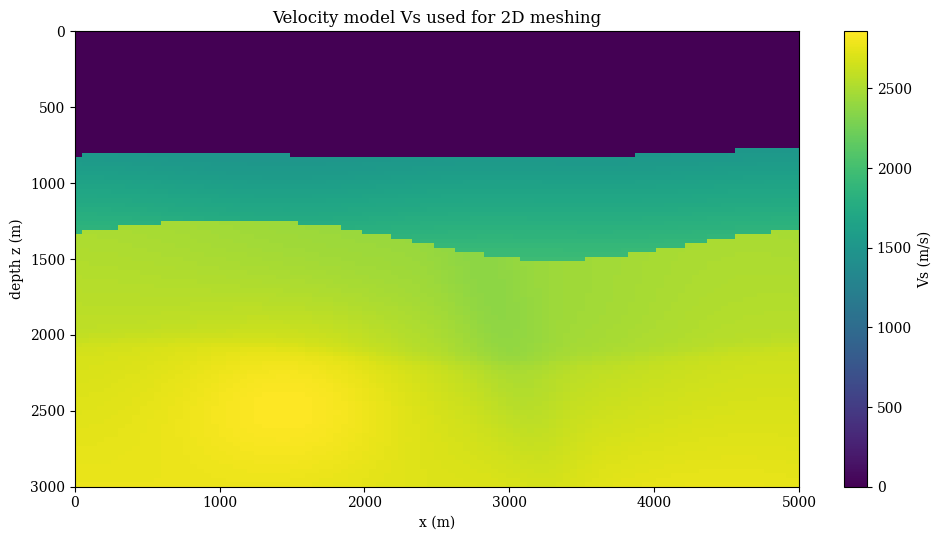

SEG-Y traces (nx):       101
Samples per trace (nz):  101
Vs range:                0.0 to 2858.7 m/s


In [3]:
with segyio.open(str(velocity_file), "r", ignore_geometry=True) as f:
    n_traces = f.tracecount
    n_samples = len(f.samples)

    vs_plane = np.column_stack(
        [
            np.asarray(f.trace[i], dtype=np.float32)
            for i in range(n_traces)
        ]
    )
if vs_plane.shape != (nz, nx):
    raise ValueError(
        f"Expected velocity plane shape {(nz, nx)}, "
        f"but read {vs_plane.shape}."
    )
x_model = np.arange(nx) * dx
z_model = np.arange(nz) * dz

fig, ax = plt.subplots(figsize=(10, 5.5))

image = ax.imshow(
    vs_plane,
    extent=[
        x_model.min(),
        x_model.max(),
        z_model.max(),
        z_model.min(),
    ],
    aspect="auto",
)

fig.colorbar(image, ax=ax, label="Vs (m/s)")

ax.set_xlabel("x (m)")
ax.set_ylabel("depth z (m)")
ax.set_title("Velocity model Vs used for 2D meshing")

plt.tight_layout()
plt.show()

print(f"SEG-Y traces (nx):       {n_traces}")
print(f"Samples per trace (nz):  {n_samples}")
print(f"Vs range:                {vs_plane.min():.1f} to {vs_plane.max():.1f} m/s")


## Spyro 2D Gmsh mesh parameters

Here we tell Spyro how we want the mesh generated, we can control the type of element (triangle or quads), structured or unstructured mesh. It is also possible to detect and generate the water interface, since our water has vs=0, we set the water search value = 0. By changing the variable mesh_example from 1 to 3, each mesh example is generated. 

In [4]:
mesh_example = 1
if mesh_example == 1:
    # Unstructured triangular mesh with rectangular padding,
    # no water interface and extended SEGY mesh size into the padding
    frequency = 10.0             # Velocity-model/source frequency in Hz
    wl = 2.0                     # Number of elements per wavelength
    grade = 0.1                 # Controls smooth element size transition, 0.9 = high smooth, 0.05 = small smooth
    hmin_segy = 0.0              # Minimum element-size limit for SEGY-based mesh sizing, leave 0.0 for no change
    padding_type = "rectangular" # Use rectangular absorbing-layer padding
    hyper_n = 4                  # Not used here; only used for hyperelliptical padding
    water_interface = False      # Do not delimit the water interface
    structured_mesh = False      # Generate an unstructured triangular mesh
    min_element_size = 200.0     # Not used here; structured-mesh size parameter
    h_padding = 500.0            # Not used here; padding size comes from extended SEGY sizing
    apply_winslow = False        # Not used here; Do not apply Winslow mesh smoothing
    extend_segy = True           # Extend the SEGY-derived mesh size into the padding
elif mesh_example == 2:
    # Unstructured triangular mesh with hyperelliptical padding,
    # delimited water interface and constant padding mesh size
    frequency = 10.0             # Velocity-model/source frequency in Hz
    wl = 2.0                     # Number of elements per wavelength
    grade = 0.1                 # Controls smooth element size transition, 0.9 = high smooth, 0.05 = small smooth
    hmin_segy = 0.0              # Minimum element-size limit for SEGY-based mesh sizing, leave 0.0 for no change
    padding_type = "hyperelliptical" # Use hyperelliptical absorbing-layer padding
    hyper_n = 4                  # Hyperellipse exponent controlling the padding shape
    water_interface = True       # Delimit the water/subsurface interface
    structured_mesh = False      # Generate an unstructured triangular mesh
    min_element_size = 200.0     # Not used here; structured-mesh size parameter
    h_padding = 500.0            # Constant element size used inside the padding
    apply_winslow = False        # Not used here; Do not apply Winslow mesh smoothing
    extend_segy = False          # Do not extend SEGY sizing; use h_padding in the padding
elif mesh_example == 3:
    # Structured quad mesh with no padding, no delimited water interface,
    # and Winslow smoothing for geometry conforming
    frequency = 10.0             # Not used here; structured mesh uses min_element_size
    wl = 2.0                     # Not used here; structured mesh uses min_element_size
    grade = 0.1                  # Controls smooth element size transition, 0.9 = high smooth, 0.05 = small smooth
    hmin_segy = 0.0              # Not used here; no SEGY-based unstructured mesh sizing, leave 0.0 for no change
    padding_type = None          # Disable padding
    hyper_n = 4                  # Not used here; there is no hyperelliptical padding
    water_interface = False      # Do not delimit the water/subsurface interface
    structured_mesh = True       # Generate a structured quadrilateral mesh
    min_element_size = 50.0      # Element size used to construct the structured mesh
    h_padding = 500.0            # Not used here; there is no padding
    apply_winslow = True         # Apply Winslow smoothing to conform the structured mesh
    extend_segy = False          # Not used here; there is no padding to extend sizing into
else:
    raise ValueError(
        f"Invalid mesh_example={mesh_example}. "
        "Choose mesh_example = 1, 2, or 3."
    )

mesh_dictionary = {
    "mesh_type": "gmsh_mesh",
    "dimension": 2,
    "length_z": domain_z,
    "length_x": domain_x,
    "output_filename": str(mesh_file),
    "cells_per_wavelength": wl,
    "source_frequency": frequency,
    "frequency": frequency,
    "grade": grade,
    "hmin_segy": hmin_segy,
    "segy_velocity_model": str(velocity_file),
    "padding_type": padding_type,
    "padding_x": padding_x,
    "padding_z": padding_z,
    "hyper_n": hyper_n,
    "water_interface": water_interface,
    "water_search_value": 0.0,
    "vp_water": 500.0,
    "structured_mesh": structured_mesh,
    "min_element_size": min_element_size,
    "extend_segy": extend_segy,
    "h_padding": h_padding,
    "apply_winslow": apply_winslow,
    "winslow_implementation": "numba",
    "winslow_iterations": 1000,
    "winslow_omega": 0.5,
}

mesh_parameters = MeshingParameters(
    input_mesh_dictionary=mesh_dictionary,
    dimension=2,
    source_frequency=frequency,
    comm=None,
    quadrilateral=False,
    method="mass_lumped_triangle",
    degree=3,
    abc_pad_length=None,
    negative_z=True,
)
for name, value in mesh_dictionary.items():
    try:
        setattr(mesh_parameters, name, value)
    except (AttributeError, TypeError, ValueError):
        pass

print("2D meshing parameters created.")


2D meshing parameters created.


/home/juninhoras/firedrakes/spyro/spyro/meshing/meshing_parameters.py:1197: UserWarning: Passing SEGY directly to the mesher is deprecated. Please use grid point velocity inputs.
  warn("Passing SEGY directly to the mesher is deprecated. Please use grid point velocity inputs.")


## Generate the 2D mesh

Using create_gmsh_2D_mesh() we will generate the .msh mesh file.

In [5]:
automatic_mesh = AutomaticMesh(mesh_parameters=mesh_parameters)
if not hasattr(
    automatic_mesh,
    "create_gmsh_2D_mesh",
):
    raise AttributeError(
        "This Spyro version does not use:"
        "AutomaticMesh.create_gmsh_2D_mesh()."
    )
# This generates rectangle_mesh_2D.msh.
automatic_mesh.create_gmsh_2D_mesh()
if not mesh_file.is_file():
    raise RuntimeError(
        f"Mesh generation finished but {mesh_file} was not created."
    )
print("2D mesh created successfully.")

Generating Gmsh mesh...
Reading SEGY file: velocity_models/vs_example_2D.segy
Final velocity range: 0.0 - 2858.7
127
133
Function Minimum and Maximum values:
20.616046113028965 142.92028782029385
Info    : Meshing 1D...nts - Splitting faces                                                                                              
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 20%] Meshing curve 3 (Line)
Info    : [ 20%] Meshing curve 4 (Line)
Info    : [ 30%] Meshing curve 5 (Line)
Info    : [ 30%] Meshing curve 6 (Line)
Info    : [ 40%] Meshing curve 7 (Line)
Info    : [ 50%] Meshing curve 8 (Line)
Info    : [ 50%] Meshing curve 9 (Line)
Info    : [ 60%] Meshing curve 10 (Line)
Info    : [ 60%] Meshing curve 11 (Line)
Info    : [ 70%] Meshing curve 12 (Line)
Info    : [ 80%] Meshing curve 13 (Line)
Info    : [ 80%] Meshing curve 14 (Line)
Info    : [ 90%] Meshing curve 15 (Line)
Info    : [ 90%] Meshing curve 16 (Line)
Info    : [100%] M

## Plot of the generated mesh

This code snippet will read the .msh file using Gmsh and extract the mesh nodes and connections for plotting. The generated mesh is then plotted using matplolib. Spyro stores the 2D coordinates in `(z, x)` order after its mesh rotation, so the plot below displays:

- horizontal axis: `x`;
- vertical axis: positive depth `-z`.


Info    : Reading 'example_mesh_2D.msh'...
Info    : 35 entities
Info    : 11975 nodes
Info    : 23521 elements
Info    : Done reading 'example_mesh_2D.msh'


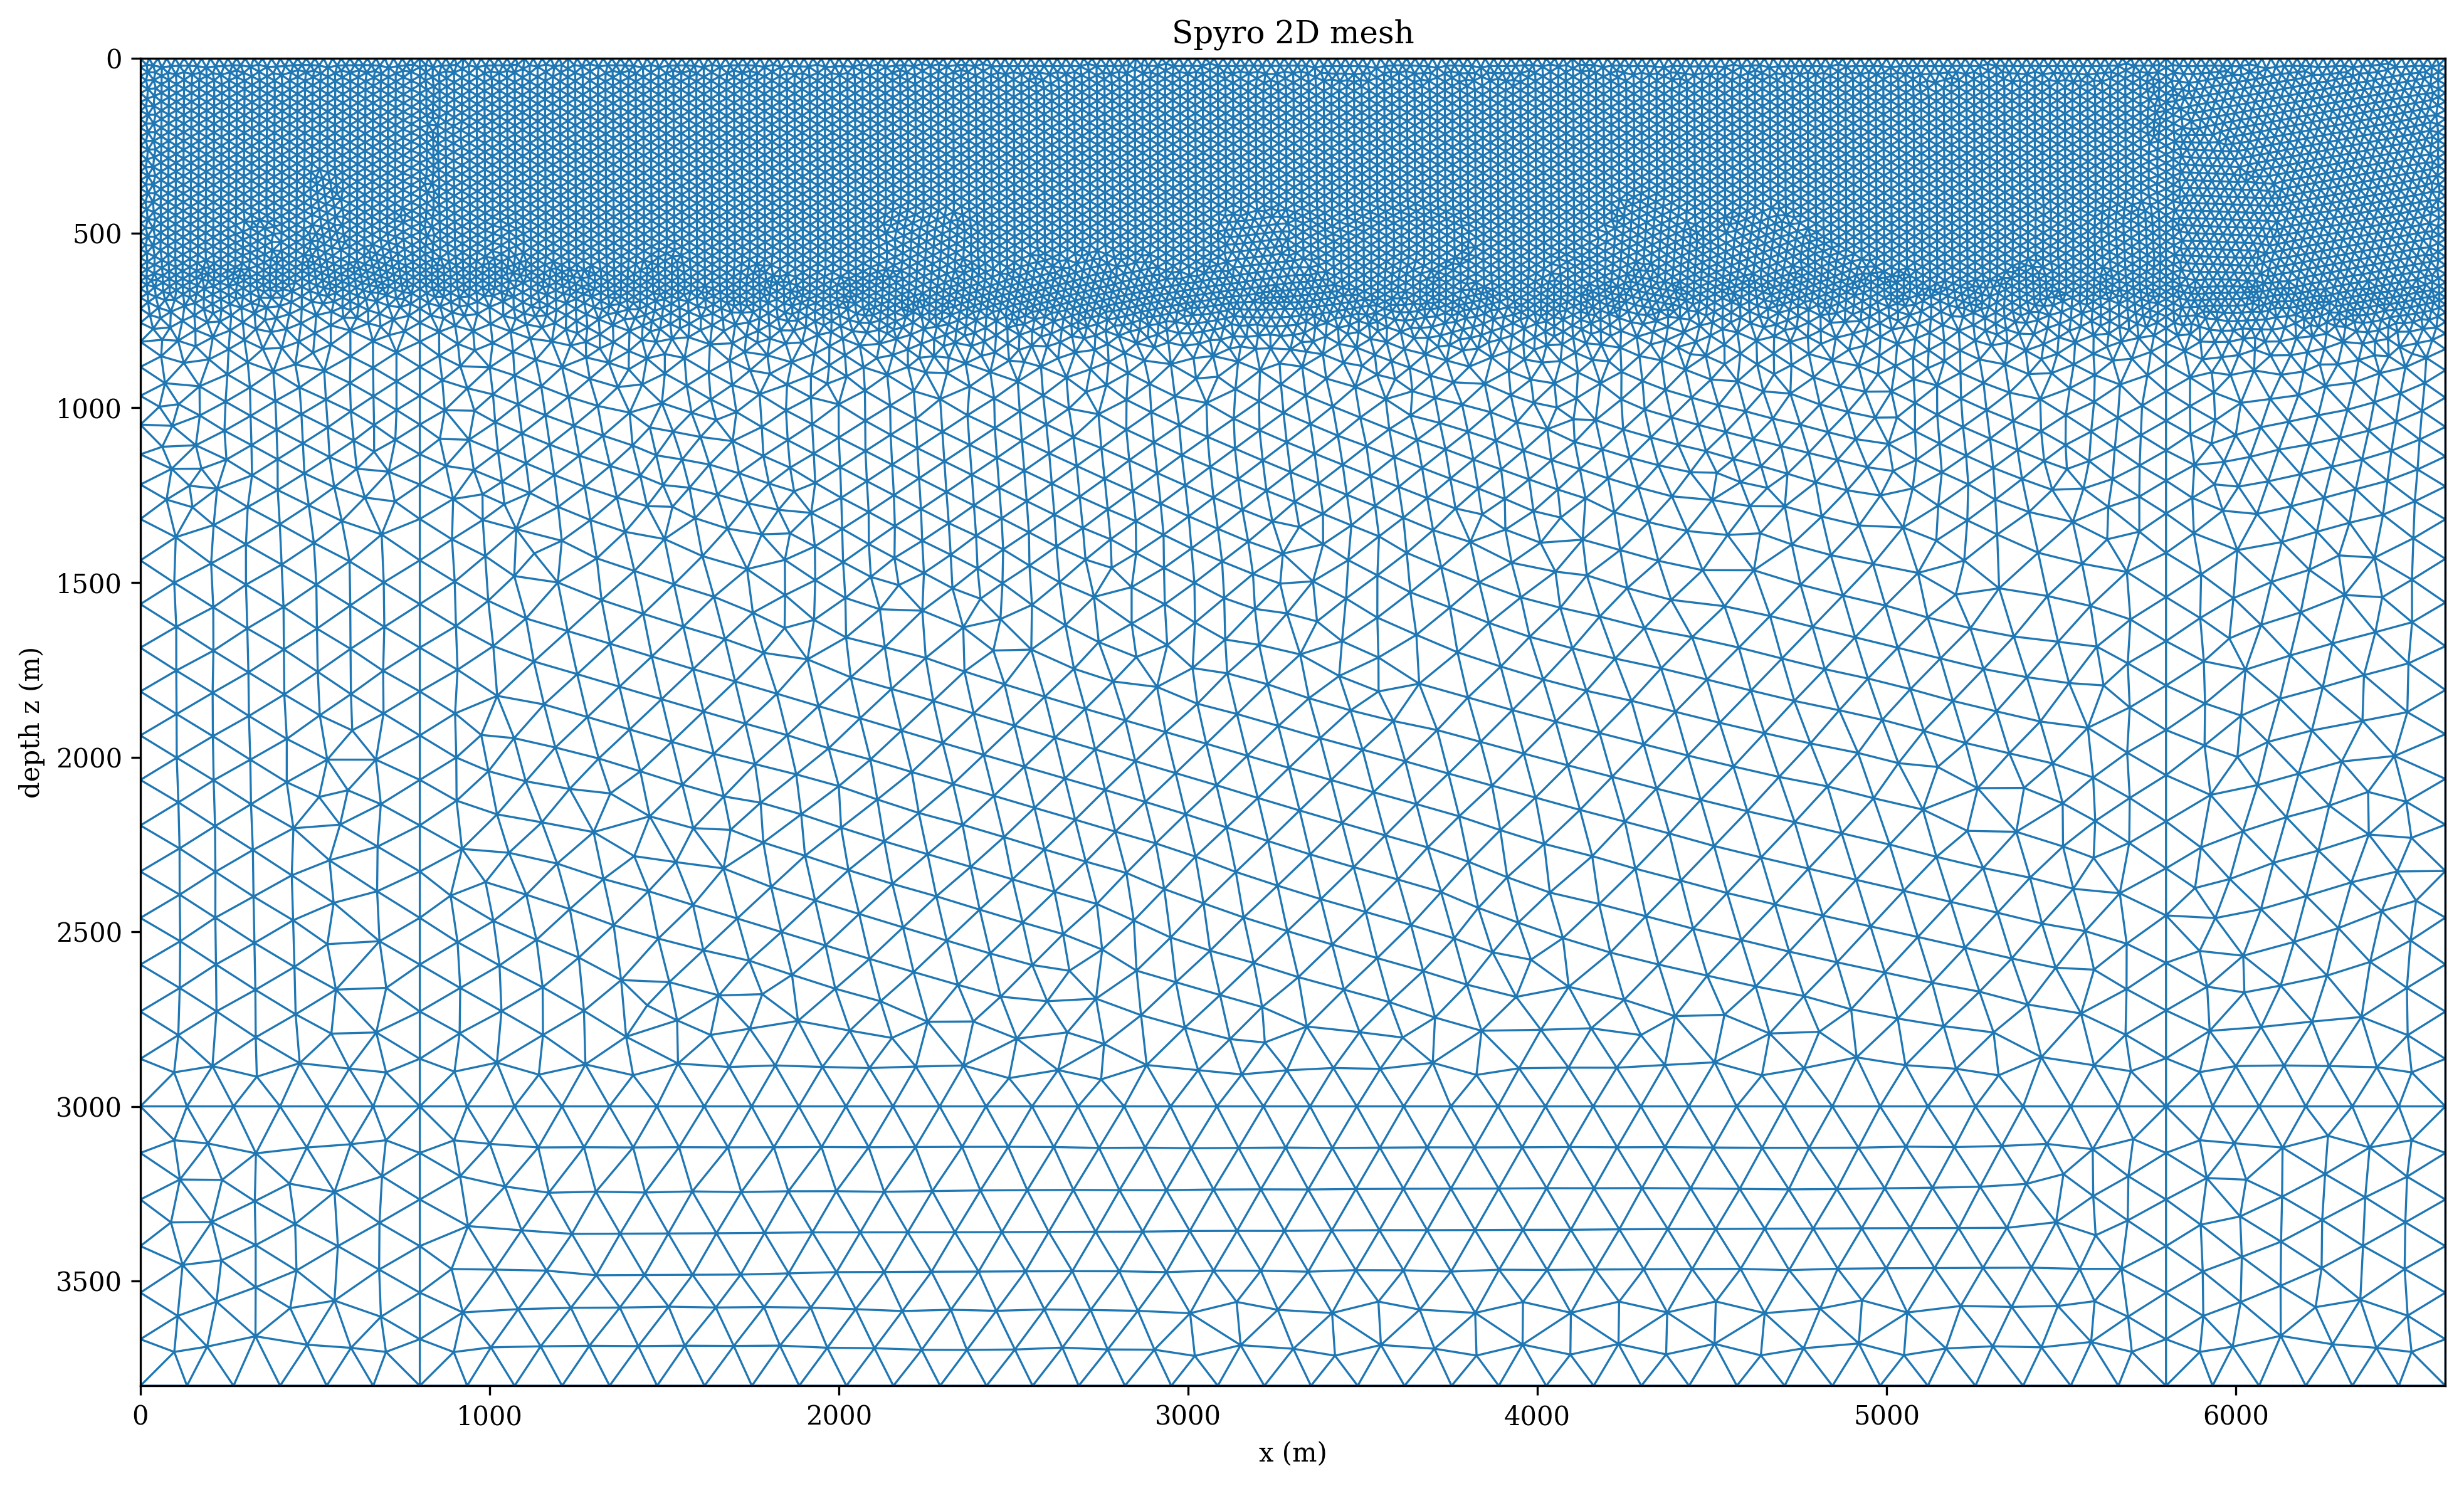

Nodes:     11,975
Triangles: 23,521
Quads:     0


In [6]:
from matplotlib.collections import LineCollection

def read_2d_mesh(msh_path):
    gmsh.initialize()
    try:
        gmsh.open(str(msh_path))
        tags, xyz, _ = gmsh.model.mesh.getNodes()
        xyz = np.asarray(xyz).reshape(-1, 3)
        idx = {int(t): i for i, t in enumerate(tags)}

        tris, quads = [], []
        types, _, nodes = gmsh.model.mesh.getElements(dim=2)

        for etype, conn in zip(types, nodes):
            name, _, _, n, _, _ = gmsh.model.mesh.getElementProperties(etype)
            c = np.asarray(conn).reshape(-1, n)

            if "triangle" in name.lower():
                tris.append([[idx[t] for t in e[:3]] for e in c])

            elif "quad" in name.lower():
                quads.append([[idx[t] for t in e[:4]] for e in c])

        return (
            xyz,
            np.vstack(tris) if tris else np.empty((0, 3), int),
            np.vstack(quads) if quads else np.empty((0, 4), int),
        )
    finally:
        gmsh.finalize()

coordinates, triangles, quads = read_2d_mesh(mesh_file)

x = coordinates[:, 1]
z = -coordinates[:, 0]
xy = np.c_[x, z]

fig, ax = plt.subplots(figsize=(14, 8), dpi=300)

if len(triangles):
    ax.triplot(x, z, triangles, linewidth=0.8)

if len(quads):
    p = xy[quads]
    lines = np.concatenate([
        p[:, [0, 1]],
        p[:, [1, 2]],
        p[:, [2, 3]],
        p[:, [3, 0]],
    ])
    ax.add_collection(LineCollection(lines, linewidths=0.8))

ax.set(
    xlabel="x (m)",
    ylabel="depth z (m)",
    title="Spyro 2D mesh",
    xlim=(x.min(), x.max()),
    ylim=(z.max(), z.min()),
)
ax.set_aspect("equal")

plt.tight_layout()
plt.savefig(figure_file, dpi=600, bbox_inches="tight")
plt.show()

print(f"Nodes:     {len(coordinates):,}")
print(f"Triangles: {len(triangles):,}")
print(f"Quads:     {len(quads):,}")

## Outputs

After running the notebook, the two exported files are:

```text
example_mesh_2D.msh
example_mesh_2D.png
```
